In [2]:
%pip install pillow

Defaulting to user installation because normal site-packages is not writeable
  Using cached pillow-12.0.0-cp312-cp312-win_amd64.whl.metadata (9.0 kB)
Using cached pillow-12.0.0-cp312-cp312-win_amd64.whl (7.0 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\gadia\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


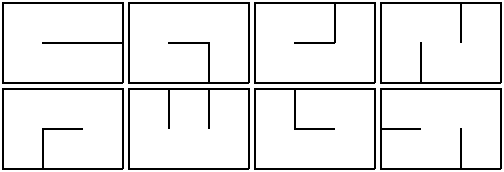

In [17]:
import random
import itertools
from PIL import Image, ImageDraw,  ImageOps


def generate_maze(width, height, seed=None):
    """
    Generate a width x height maze using recursive backtracker.
    Returns (vertical_walls, horizontal_walls).

    vertical_walls[x][y] = wall between cell (x-1,y) and (x,y)
       x = 0..width, y = 0..height-1
    horizontal_walls[x][y] = wall between cell (x,y-1) and (x,y)
       x = 0..width-1, y = 0..height
    """
    if seed is not None:
        random.seed(seed)

    # All walls start present
    vertical_walls   = [[True] * height       for _ in range(width + 1)]
    horizontal_walls = [[True] * (height + 1) for _ in range(width)]

    visited = [[False] * height for _ in range(width)]
    stack = [(0, 0)]
    visited[0][0] = True

    # Directions: (dx, dy, label)
    directions = [
        (0, -1, "N"),
        (0,  1, "S"),
        (-1, 0, "W"),
        (1,  0, "E"),
    ]

    while stack:
        x, y = stack[-1]

        # unvisited neighbors
        neighbors = []
        for dx, dy, d in directions:
            nx, ny = x + dx, y + dy
            if 0 <= nx < width and 0 <= ny < height and not visited[nx][ny]:
                neighbors.append((nx, ny, d))

        if neighbors:
            nx, ny, d = random.choice(neighbors)

            # carve wall between (x,y) and (nx,ny)
            if d == "N":
                # remove wall above (x,y)
                horizontal_walls[x][y] = False
            elif d == "S":
                horizontal_walls[x][y + 1] = False
            elif d == "W":
                vertical_walls[x][y] = False
            elif d == "E":
                vertical_walls[x + 1][y] = False

            visited[nx][ny] = True
            stack.append((nx, ny))
        else:
            stack.pop()

    return vertical_walls, horizontal_walls


def draw_maze(vertical_walls, horizontal_walls,
              cell_size=18, wall_width=2, margin=2):
    """
    Draws the maze using Pillow and returns a PIL.Image.
    """
    width = len(horizontal_walls)          # number of cells in x
    height = len(horizontal_walls[0]) - 1  # number of cells in y

    img_w = width * cell_size + wall_width + 2 * margin
    img_h = height * cell_size + wall_width + 2 * margin

    img = Image.new("L", (img_w, img_h), 255)  # white background
    draw = ImageDraw.Draw(img)

    # Vertical walls
    for x in range(width + 1):
        for y in range(height):
            if vertical_walls[x][y]:
                x0 = margin + x * cell_size
                y0 = margin + y * cell_size
                x1 = x0
                y1 = y0 + cell_size
                draw.line((x0, y0, x1, y1), fill=0, width=wall_width)

    # Horizontal walls
    for x in range(width):
        for y in range(height + 1):
            if horizontal_walls[x][y]:
                x0 = margin + x * cell_size
                y0 = margin + y * cell_size
                x1 = x0 + cell_size
                y1 = y0
                draw.line((x0, y0, x1, y1), fill=0, width=wall_width)

    return img




# -----------------------------
# Helper: neighbors in grid
# -----------------------------
def neighbors(x, y, W, H):
    if x > 0:       yield (x-1, y)
    if x < W-1:     yield (x+1, y)
    if y > 0:       yield (x, y-1)
    if y < H-1:     yield (x, y+1)


# -------------------------------------------------------------
# Enumerate all perfect mazes as spanning trees of the grid
# -------------------------------------------------------------
# -------------------------------------------------------------
# Enumerate all perfect mazes as spanning trees of the grid
# -------------------------------------------------------------
def enumerate_all_mazes(W, H):
    """
    Enumerate all *unique* perfect mazes (spanning trees) on a W×H grid.
    No duplicates. Canonical order.
    """

    # init all walls
    def init_walls():
        V = [[True] * H for _ in range(W + 1)]
        HZ = [[True] * (H + 1) for _ in range(W)]
        return V, HZ

    visited = [[False]*H for _ in range(W)]
    visited[0][0] = True
    vertical, horizontal = init_walls()
    total = W*H

    def frontier():
        edges = []
        for x in range(W):
            for y in range(H):
                if visited[x][y]:
                    for nx, ny in neighbors(x, y, W, H):
                        if not visited[nx][ny]:
                            edges.append((x,y,nx,ny))
        return sorted(edges)   # canonical lexicographic ordering

    def carve(x, y, nx, ny, val):
        if nx == x and ny == y-1:      # N
            horizontal[x][y] = val
        elif nx == x and ny == y+1:    # S
            horizontal[x][y+1] = val
        elif nx == x-1 and ny == y:    # W
            vertical[x][y] = val
        elif nx == x+1 and ny == y:    # E
            vertical[x+1][y] = val

    def dfs(visited_count, last_edge_index):
        if visited_count == total:
            yield ([row[:] for row in vertical],
                   [row[:] for row in horizontal])
            return

        edges = frontier()

        # only edges AFTER last_edge_index => avoid permuting identical trees
        for i in range(last_edge_index, len(edges)):
            x, y, nx, ny = edges[i]

            carved_before = not visited[nx][ny]

            carve(x, y, nx, ny, False)
            visited[nx][ny] = True

            yield from dfs(visited_count + (1 if carved_before else 0), i)

            visited[nx][ny] = False
            carve(x, y, nx, ny, True)

    # start at edge index 0
    yield from dfs(1, 0)

def make_montage(images, cols, bg=255):
    """
    Create a montage from a list of PIL.Image objects.
    Works on all Pillow versions.
    """
    if not images:
        raise ValueError("Image list is empty")

    w, h = images[0].size
    n = len(images)
    rows = (n + cols - 1) // cols

    # Create new blank canvas
    montage = Image.new("L", (cols * w, rows * h), bg)

    for idx, img in enumerate(images):
        r = idx // cols
        c = idx % cols
        montage.paste(img, (c * w, r * h))

    return montage

mazes = list(enumerate_all_mazes(3,2))
imgs = [draw_maze(V, HZ, cell_size=40) for V, HZ in mazes]
montage = make_montage(imgs, cols=4)
display(montage)

In [ ]:
from itertools import combinations

def all_edges(W, H):
    """
    Return a list of undirected edges in the grid:
    each edge is ((x1,y1),(x2,y2))
    """
    E = []
    for x in range(W):
        for y in range(H):
            if x+1 < W: E.append(((x,y),(x+1,y)))
            if y+1 < H: E.append(((x,y),(x,y+1)))
    return E


def find(a, parent):
    while parent[a] != a:
        parent[a] = parent[parent[a]]
        a = parent[a]
    return a

def union(a, b, parent, rank):
    a = find(a, parent)
    b = find(b, parent)
    if a == b:
        return False  # cycle
    if rank[a] < rank[b]:
        a,b = b,a
    parent[b] = a
    if rank[a] == rank[b]:
        rank[a] += 1
    return True


def is_spanning_tree(subset, W, H):
    """
    Given a subset of edges (N-1 edges), test:
    • no cycles
    • fully connected
    """
    N = W*H
    parent = list(range(N))
    rank = [0]*N

    count = 0

    for (x1,y1),(x2,y2) in subset:
        a = y1*W + x1
        b = y2*W + x2
        if not union(a, b, parent, rank):
            return False    # cycle
        count += 1

    # must have exactly N-1 edges
    if count != N-1:
        return False

    # check single connected component
    root = find(0,parent)
    for i in range(N):
        if find(i,parent) != root:
            return False

    return True


def enumerate_all_mazes(W, H):
    """
    Enumerate all perfect mazes on W×H using brute-force
    spanning-tree testing.
    Returns a list of edge sets.
    """
    E = all_edges(W,H)
    N = W*H
    results = []

    for subset in combinations(E, N-1):
        if is_spanning_tree(subset, W, H):
            results.append(subset)

    return results

def edges_to_walls(edge_set, W, H):
    V = [[True]*H for _ in range(W+1)]
    HZ = [[True]*(H+1) for _ in range(W)]

    for (x1,y1),(x2,y2) in edge_set:
        if x1==x2:
            # vertical movement, remove horizontal wall
            if y2 == y1+1:
                HZ[x1][y2] = False
            else:
                HZ[x1][y1] = False
        else:
            # horizontal movement, remove vertical wall
            if x2 == x1+1:
                V[x2][y1] = False
            else:
                V[x1][y1] = False

    return V, HZ
mazes = enumerate_all_mazes(3,2)
print(len(mazes))
# imgs = [draw_maze(V, HZ, cell_size=40) for V, HZ in mazes]
# montage = make_montage(imgs, cols=4)
# display(montage)


15


In [ ]:
import numpy as np

L = np.array([
    [ 2, -1,  0, -1,  0,  0],
    [-1,  3, -1,  0, -1,  0],
    [ 0, -1,  2,  0,  0, -1],
    [-1,  0,  0,  2, -1,  0],
    [ 0, -1,  0, -1,  3, -1],
    [ 0,  0, -1,  0, -1,  2]
], dtype=int)

print(np.linalg.det(L))
Lm = L[1:,1:]
print(Lm)
print(np.linalg.det(Lm))